# EUV Line Grating Imaging Analysis

This notebook analyzes a 52 nm CD / 104 nm pitch line grating under 6 degree incidence with illumination NA = PO NA = 0.33 / 4. The pupil coordinates are shown in absolute NA coordinates, with the PO center at `sin(6 deg)`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root))

from fourier_optics import HopkinsImagingModel
from examples.run_line_grating_task import (
    contrast,
    diffraction_order_amplitudes,
    equal_radius_overlap_fraction,
    line_grating,
)

In [2]:
wavelength = 13.5e-9
cd = 52e-9
pitch = 104e-9
incident_angle_deg = 6.0
illumination_na = 0.33 / 4
po_na = illumination_na
pixel_size = 1e-9
shape = (256, 1040)

pupil_center_na = np.sin(np.deg2rad(incident_angle_deg))
order_spacing_na = wavelength / pitch
capture_limit = illumination_na + po_na
first_order_overlap = equal_radius_overlap_fraction(order_spacing_na, po_na)

print(f"wavelength = {wavelength * 1e9:.3f} nm")
print(f"CD = {cd * 1e9:.3f} nm")
print(f"pitch = {pitch * 1e9:.3f} nm")
print(f"PO center NAx = sin(6 deg) = {pupil_center_na:.6f}")
print(f"illumination NA = {illumination_na:.6f}")
print(f"PO NA = {po_na:.6f}")
print(f"first-order spacing in NA = lambda / pitch = {order_spacing_na:.6f}")
print(f"partial-coherence capture limit = NAillum + NApo = {capture_limit:.6f}")
print(f"first-order disk overlap with PO = {first_order_overlap:.2%}")

wavelength = 13.500 nm
CD = 52.000 nm
pitch = 104.000 nm
PO center NAx = sin(6 deg) = 0.104528
illumination NA = 0.082500
PO NA = 0.082500
first-order spacing in NA = lambda / pitch = 0.129808
partial-coherence capture limit = NAillum + NApo = 0.165000
first-order disk overlap with PO = 11.44%


The first-order diffraction centers are outside the PO because `lambda / pitch > PO NA`. However, with finite illumination, each diffraction order is broadened by the illumination NA. Since `lambda / pitch < NAillum + NApo`, the `m=±1` illumination disks partially overlap the PO and contribute to imaging.

In [3]:
orders, amplitudes = diffraction_order_amplitudes(max_order=5)
order_na_x = pupil_center_na + orders * order_spacing_na
order_energy = amplitudes**2

rows = []
for order, x, energy in zip(orders, order_na_x, order_energy):
    center_distance = abs(x - pupil_center_na)
    overlap = equal_radius_overlap_fraction(center_distance, po_na)
    rows.append((order, x, energy, center_distance <= po_na, overlap, energy * overlap))

print("m    center_NAx    energy      center_in_PO    area_overlap    captured_energy")
for row in rows:
    print(f"{row[0]:+d}   {row[1]: .6f}    {row[2]:.6f}    {str(row[3]):>5s}         {row[4]:.6%}      {row[5]:.6f}")

m    center_NAx    energy      center_in_PO    area_overlap    captured_energy
-5   -0.544510    0.004053    False         0.000000%      0.000000
-4   -0.414702    0.000000    False         0.000000%      0.000000
-3   -0.284895    0.011258    False         0.000000%      0.000000
-2   -0.155087    0.000000    False         0.000000%      0.000000
-1   -0.025279    0.101321    False         11.438593%      0.011590
+0    0.104528    0.250000     True         100.000000%      0.250000
+1    0.234336    0.101321    False         11.438593%      0.011590
+2    0.364144    0.000000    False         0.000000%      0.000000
+3    0.493952    0.011258    False         0.000000%      0.000000
+4    0.623759    0.000000    False         0.000000%      0.000000
+5    0.753567    0.004053    False         0.000000%      0.000000


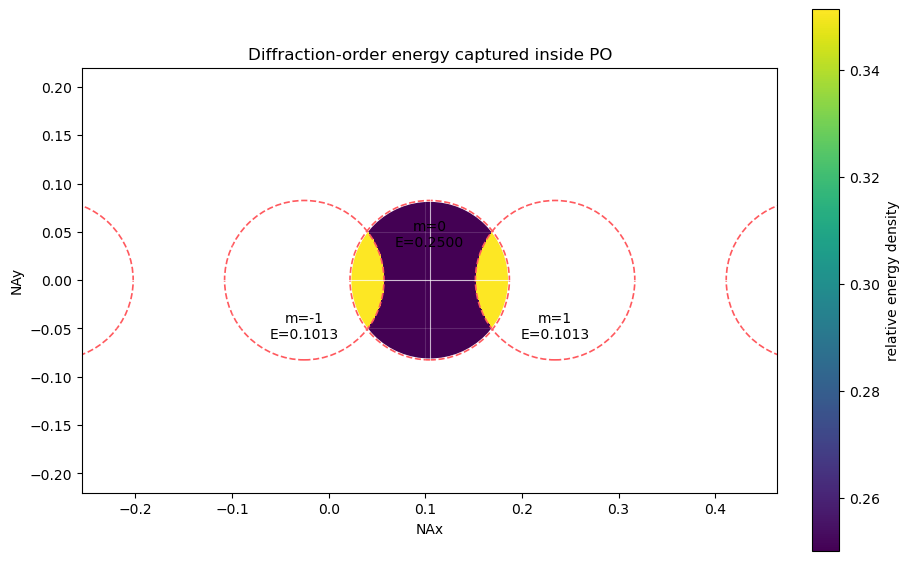

In [4]:
x_min = pupil_center_na - 0.36
x_max = pupil_center_na + 0.36
y_min = -0.22
y_max = 0.22
x_axis = np.linspace(x_min, x_max, 900)
y_axis = np.linspace(y_min, y_max, 550)
x_grid, y_grid = np.meshgrid(x_axis, y_axis)
po_mask = (x_grid - pupil_center_na) ** 2 + y_grid**2 <= po_na**2
energy_map = np.zeros_like(x_grid)

for center_x, energy in zip(order_na_x, order_energy):
    if energy == 0:
        continue
    source_disk = (x_grid - center_x) ** 2 + y_grid**2 <= illumination_na**2
    energy_map[source_disk] += energy

captured_map = np.where(po_mask, energy_map, np.nan)

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
im = ax.imshow(captured_map, extent=[x_min, x_max, y_min, y_max], origin="lower", cmap="viridis", aspect="equal", interpolation="nearest")
fig.colorbar(im, ax=ax, label="relative energy density")
ax.add_patch(plt.Circle((pupil_center_na, 0), po_na, fill=False, color="white", linewidth=2.0))
for order, center_x, energy in zip(orders, order_na_x, order_energy):
    if energy == 0:
        continue
    ax.add_patch(plt.Circle((center_x, 0), illumination_na, fill=False, color="#ff595e", linewidth=1.2, linestyle="--"))
    if abs(center_x - pupil_center_na) < 0.25:
        ax.annotate(f"m={order}\nE={energy:.4f}", xy=(center_x, 0), xytext=(0, -42 if order else 24), textcoords="offset points", ha="center")
ax.axvline(pupil_center_na, color="white", linewidth=0.8, alpha=0.7)
ax.axhline(0, color="white", linewidth=0.8, alpha=0.7)
ax.set_title("Diffraction-order energy captured inside PO")
ax.set_xlabel("NAx")
ax.set_ylabel("NAy")
ax.grid(True, color="white", alpha=0.15)
plt.show()

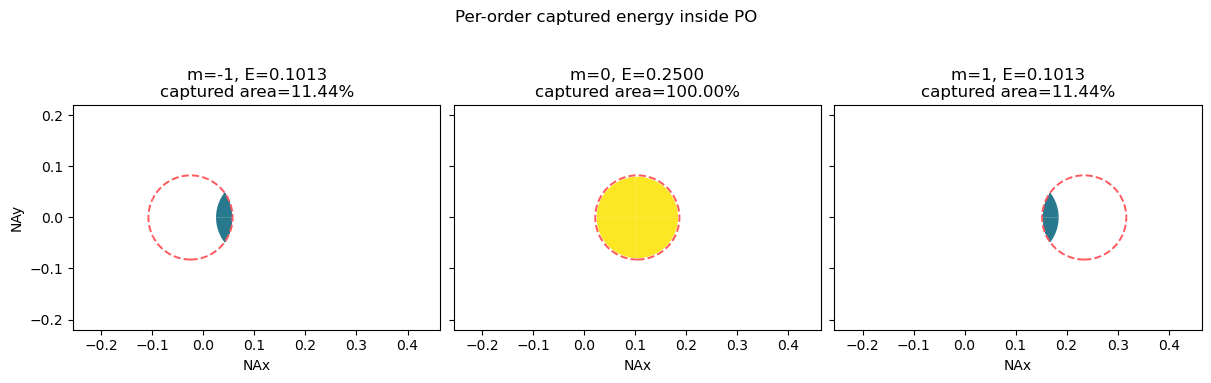

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, constrained_layout=True)
for ax, order in zip(axes, [-1, 0, 1]):
    center_x = pupil_center_na + order * order_spacing_na
    energy = 0.5**2 if order == 0 else (1 / np.pi) ** 2
    source_disk = (x_grid - center_x) ** 2 + y_grid**2 <= illumination_na**2
    captured = np.where(po_mask & source_disk, energy, np.nan)
    ax.imshow(captured, extent=[x_min, x_max, y_min, y_max], origin="lower", cmap="viridis", aspect="equal", vmin=0, vmax=0.25, interpolation="nearest")
    ax.add_patch(plt.Circle((pupil_center_na, 0), po_na, fill=False, color="white", linewidth=2.0))
    ax.add_patch(plt.Circle((center_x, 0), illumination_na, fill=False, color="#ff595e", linewidth=1.4, linestyle="--"))
    overlap = equal_radius_overlap_fraction(abs(center_x - pupil_center_na), po_na)
    ax.set_title(f"m={order}, E={energy:.4f}\ncaptured area={overlap:.2%}")
    ax.set_xlabel("NAx")
    ax.grid(True, color="white", alpha=0.15)
axes[0].set_ylabel("NAy")
fig.suptitle("Per-order captured energy inside PO")
plt.show()

In [6]:
field = line_grating(shape=shape, pixel_size=pixel_size, cd=cd, pitch=pitch, line_amplitude=1.0, space_amplitude=0.0)
model = HopkinsImagingModel(
    wavelength=wavelength,
    numerical_aperture=po_na,
    pixel_size=pixel_size,
    source_sigma=illumination_na / po_na,
    source_samples=31,
)
image = model.image_intensity(field)

print(f"min = {np.min(image):.9g}")
print(f"max = {np.max(image):.9g}")
print(f"mean = {np.mean(image):.9g}")
print(f"contrast = {contrast(image):.9g}")

min = 0.19955289
max = 0.347600952
mean = 0.273576921
contrast = 0.270578494


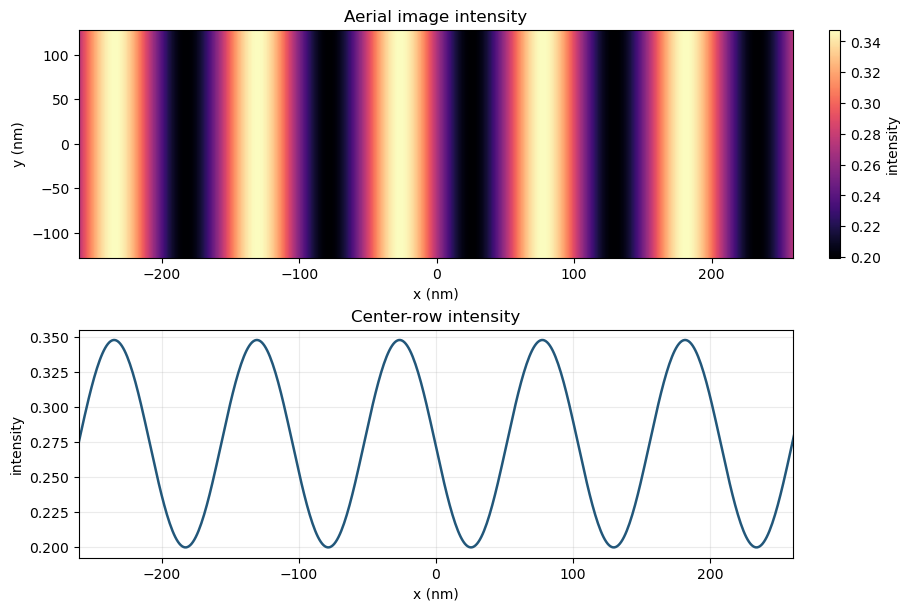

In [7]:
center_row = image[shape[0] // 2]
x_nm = (np.arange(shape[1]) - shape[1] / 2) * pixel_size * 1e9
crop_half_width = int(round(2.5 * pitch / pixel_size))
center = shape[1] // 2
crop = image[:, center - crop_half_width : center + crop_half_width]
crop_x = x_nm[center - crop_half_width : center + crop_half_width]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), constrained_layout=True)
extent = [crop_x[0], crop_x[-1], -shape[0] * pixel_size * 0.5e9, shape[0] * pixel_size * 0.5e9]
im = axes[0].imshow(crop, cmap="magma", aspect="auto", extent=extent, origin="lower")
fig.colorbar(im, ax=axes[0], label="intensity")
axes[0].set_title("Aerial image intensity")
axes[0].set_xlabel("x (nm)")
axes[0].set_ylabel("y (nm)")

axes[1].plot(x_nm, center_row, color="#22577a", linewidth=1.8)
axes[1].set_xlim(-2.5 * pitch * 1e9, 2.5 * pitch * 1e9)
axes[1].set_title("Center-row intensity")
axes[1].set_xlabel("x (nm)")
axes[1].set_ylabel("intensity")
axes[1].grid(True, alpha=0.25)
plt.show()